# Unit 4.1 Exercise
Luis Rafael L. Ajoc
BSCS 3A AI

## Setup

### Create dataset

In [29]:
data = {
    "Free money now!!!": "SPAM",
    "Hi mom, how are you?": "HAM",
    "Lowest price for your meds": "SPAM",
    "Are we still on for dinner?": "HAM",
    "Win a free iPhone today": "SPAM",
    "Let&#39;s catch up tomorrow at the office": "HAM",
    "Meeting at 3 PM tomorrow": "HAM",
    "Get 50% off, limited time!": "SPAM",
    "Team meeting in the office": "HAM",
    "Click here for prizes!": "SPAM",
    "Can you send the report?": "HAM",
}

test = ["Limited offer, click here!", "Meeting at 2 PM with the manager."]

## Manual Implementation

In [30]:
from collections import Counter
import string

# Preprocessing function
def preprocess_documents(data):
    processed_data = dict()
    for document, type in data.items():
        document = document.lower()
        document = document.translate(str.maketrans("", "", string.punctuation))
        processed_data[document] = type

    return processed_data

# Bag of words function
def create_bag_of_words(document, token):
    return document.count(token)

# Prior function
def calculate_prior_prob(class_count, document_count):
    return class_count/document_count

# Likelihood function with Laplace smoothing
def calculate_likelihood(token, document, vocab_len):
    return (document.count(token) + 1)/(len(document) + vocab_len)

# Vocabulary function
def create_vocabulary(data):
    combined_documents = " ".join(data.keys())
    unique_words = set(combined_documents.split())
    return sorted(list(unique_words))

# Classifier
def naive_bayes_classifier(test_documents, documents):
    # Get each unique class
    doc_classes = set(documents.values())

    vocabulary = create_vocabulary(documents)
    vocab_len = len(vocabulary) # Count unique words

    words_per_class = {}
    prior_prob_per_class = {}
    for doc_class in doc_classes:
        matching_keys = [key for key, value in documents.items() if value == doc_class]
        words_per_class[doc_class] = " ".join(matching_keys)
        prior_prob_per_class[doc_class] = calculate_prior_prob(len(matching_keys),len(documents))

    for test in test_documents:
        scores = {}
        for doc_class in doc_classes:
            score = prior_prob_per_class[doc_class]
            for word in test.split():
                score = score * calculate_likelihood(word, test, vocab_len)
            scores[doc_class] = score
        predicted_class = max(scores, key=scores.get)
        print(scores)

        print(f"{test}: {predicted_class}")

In [31]:
# Normalized data
processed_data = preprocess_documents(data)
print(processed_data)

{'free money now': 'SPAM', 'hi mom how are you': 'HAM', 'lowest price for your meds': 'SPAM', 'are we still on for dinner': 'HAM', 'win a free iphone today': 'SPAM', 'let39s catch up tomorrow at the office': 'HAM', 'meeting at 3 pm tomorrow': 'HAM', 'get 50 off limited time': 'SPAM', 'team meeting in the office': 'HAM', 'click here for prizes': 'SPAM', 'can you send the report': 'HAM'}


In [32]:
# Run classifier
naive_bayes_classifier(test, processed_data)

{'SPAM': 3.0290409299155653e-07, 'HAM': 3.6348491158986776e-07}
Limited offer, click here!: HAM
{'SPAM': 3.625368964756297e-12, 'HAM': 4.350442757707555e-12}
Meeting at 2 PM with the manager.: HAM



## Scikit-Learn Implementation

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
X = np.array(list(processed_data.keys()))
y = np.array(list(processed_data.values()))

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [37]:
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

MultinomialNB()

In [38]:
y_pred = model.predict(X_test_vectorized)

Accuracy: 66.66666666666666%


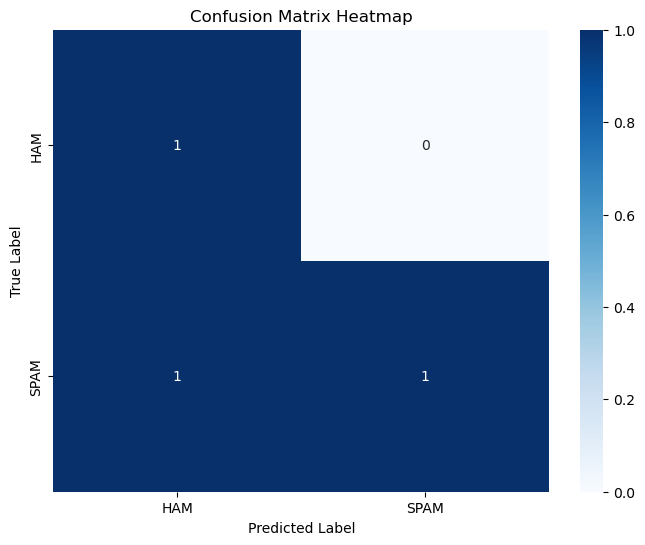

In [39]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy *100}%')

class_labels = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
for document in test:
    test_document_vectorized = vectorizer.transform([document])
    predicted_label = model.predict(test_document_vectorized)
    print(f"'{document}' is {predicted_label[0]}")

'Limited offer, click here!' is ['SPAM']
'Meeting at 2 PM with the manager.' is ['HAM']
